In [1]:
import numpy as np

from scipy.spatial.transform import Rotation

from tracing.tracer import Tracer

from optics.source import Source
from optics.mirror import Mirror
from optics.detector import Detector
from optics.beamsplitter import BeamSplitter

from plotting.views import (
    plot_system,
)


===== root.T.T =====
000  L=101.015151  n=1.000  OPL=101.015151
001  L=98.994848  n=1.000  OPL=98.994848
002  L=97.034554  n=1.000  OPL=97.034554
003  L=112.975945  n=1.000  OPL=112.975945

Total geometric length: 410.0204994875255
Total optical length: 410.0204994875255
Amplitude: 0.5000000000000001
Phase: 4071167474.7510357
root.T.T detector

===== root.T.R =====
000  L=101.015151  n=1.000  OPL=101.015151
001  L=98.994848  n=1.000  OPL=98.994848
002  L=97.034554  n=1.000  OPL=97.034554
003  L=102.975445  n=1.000  OPL=102.975445

Total geometric length: 400.01999950002494
Total optical length: 400.01999950002494
Amplitude: 0.5000000000000001
Phase: 3971870707.074182
root.T.R detector

===== root.R.T =====
000  L=101.015151  n=1.000  OPL=101.015151
001  L=98.994848  n=1.000  OPL=98.994848
002  L=97.034554  n=1.000  OPL=97.034554
003  L=102.975445  n=1.000  OPL=102.975445

Total geometric length: 400.01999950002494
Total optical length: 400.01999950002494
Amplitude: 0.5000000000000001


(<Figure size 800x600 with 1 Axes>, <Axes: >)

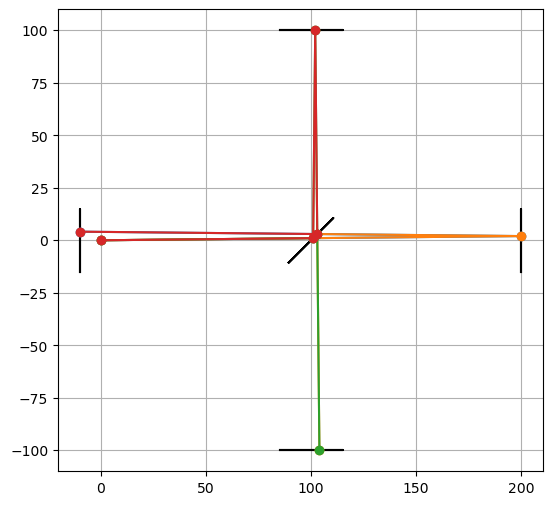

In [3]:
tracer = Tracer()

mirror1 = Mirror(
    name="M1",
    position=[100, 0, 100],
    rotation=Rotation.identity(),
    width=30,
    height=30,
)

mirror2 = Mirror(
    name="M2",
    position=[200, 0, 0],
    rotation=Rotation.from_euler(
        "y",
        -90,
        degrees=True
    ),
    width=30,
    height=30,
)

bs = BeamSplitter(
    R=0.5,
    T=0.5,
    max_generation_depth=2,

    position=[100,0,0],

    rotation=Rotation.from_euler(
        "y",
        -45,
        degrees=True
    ),

    width=30,
    height=30,
)

detector1 = Detector(
    name="DET1",

    position=[-10, 0, 0],

    rotation=Rotation.from_euler(
        "y",
        -90,
        degrees=True
    ),

    width=30,
    height=30,
)

detector2 = Detector(
    name="DET2",

    position=[100, 0, -100],

    rotation=Rotation.identity(),

    width=30,
    height=30,
)

tracer.add_element(bs)
tracer.add_element(mirror1)
tracer.add_element(mirror2)
tracer.add_element(detector1)
tracer.add_element(detector2)

source = Source(
    position=[0,0,0],
    direction=[1,0,0.01],
    wavelength=632.8e-9,
)

initial_ray = source.emit()

rays = tracer.trace(
    initial_ray
)

for ray in rays:
    ray.summary()
    print(
        ray.branch_id,
        ray.termination_reason
    )

plot_system(
    tracer,
    rays,
    view="xz",
)